# Digitalna obrada govornog signala sa mrežnom smetnjom od 50 Hz

U ovom projektu analizira se kratak govorni signal u WAV formatu.  
Na originalni govorni signal dodaje se mrežna smetnja frekvencije 50 Hz, koja predstavlja realan problem kod audio snimanja usled uticaja električne mreže, napajanja računara, punjača ili okolnih električnih uređaja.

Cilj projekta je da se prikaže uticaj mrežne smetnje na govorni signal, izvrši analiza signala u vremenskom i frekvencijskom domenu, a zatim projektuju i uporede dva tipa digitalnih filtera:

- Butterworth IIR filter,
- FIR filter projektovan prozorskom metodom.

Nakon filtriranja porede se originalni signal, signal sa dodatom smetnjom i filtrirani signali.

## 1. Uvoz biblioteka

Na početku se uvoze biblioteke potrebne za numeričku obradu, učitavanje WAV fajla, prikaz grafika, Furijeovu analizu, projektovanje digitalnih filtera i preslušavanje audio signala u Jupyter Notebook-u.

In [48]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy import signal
from IPython.display import Audio

In [49]:
# Podešavanje prikaza grafika
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

## 2. Učitavanje govornog signala

U ovom delu se učitava govorni signal koji ćemo obraditi.

Za obradu je korišćen sopstveni govorni snimak pod nazivom `SnimakGlasa.wav`. 
Snimak je mono, frekvencije odabiranja 16 kHz i trajanja približno 20 s. 
Signal je snimljen mikrofonom/laptopom i predstavlja realan diskretni govorni signal.

Nakon učitavanja prikazuju se osnovne informacije o signalu:

- frekvencija odabiranja,
- broj odbiraka,
- trajanje signala,
- maksimalna amplituda.

In [50]:
# Naziv audio fajla
filename = "Audio/SnimakGlasa.wav"

# Učitavanje WAV fajla
fs, x = wavfile.read(filename)

# Provera dimenzije signala
print(f"Dimenzija učitanog signala: {x.shape}")
print(f"Tip podataka pre obrade: {x.dtype}")

Dimenzija učitanog signala: (319760,)
Tip podataka pre obrade: int16


Originalni WAV signal je učitan u svom početnom formatu, a zatim je za potrebe obrade konvertovan u `float` format i normalizovan na opseg od -1 do 1. Normalizacija omogućava jednostavnije dodavanje mrežne smetnje kontrolisane amplitude i poređenje rezultata filtriranja.

In [51]:
# Pretvaranje u float format
x = x.astype(float)

# Normalizacija signala na opseg [-1, 1]
x = x / np.max(np.abs(x)) # normalizacija se radi da bi se lakše baratalo sa amplitudom smetnje, u originalnom fajlu je amplituda 6.5 decibela, provera kroz Audacity

# Osnovni parametri signala
N = len(x)
duration = N / fs
max_amplitude = np.max(np.abs(x)) # bice 1 nakon normalizacije naravno

print(f"Frekvencija odabiranja: {fs} Hz")
print(f"Broj odbiraka: {N}")
print(f"Trajanje signala: {duration:.2f} s")
print(f"Maksimalna amplituda nakon normalizacije: {max_amplitude:.2f}")

Frekvencija odabiranja: 16000 Hz
Broj odbiraka: 319760
Trajanje signala: 19.98 s
Maksimalna amplituda nakon normalizacije: 1.00


In [52]:
# Vremenska osa
t = np.arange(N) / fs

## 3. Preslušavanje originalnog signala

Pre dodavanja mrežne smetnje, originalni govorni signal se može preslušati direktno u notebook-u. Na ovaj način se proverava da li je signal pravilno učitan i da li odgovara očekivanom govornom sadržaju.

In [ ]:
Audio(x, rate=fs)

## 4. Prikaz originalnog signala u vremenskom domenu

Govorni signal se prvo prikazuje u vremenskom domenu. Na horizontalnoj osi nalazi se vreme u sekundama, dok je na vertikalnoj osi normalizovana amplituda signala.

Ovaj prikaz omogućava uvid u promenu amplitude govora tokom vremena.

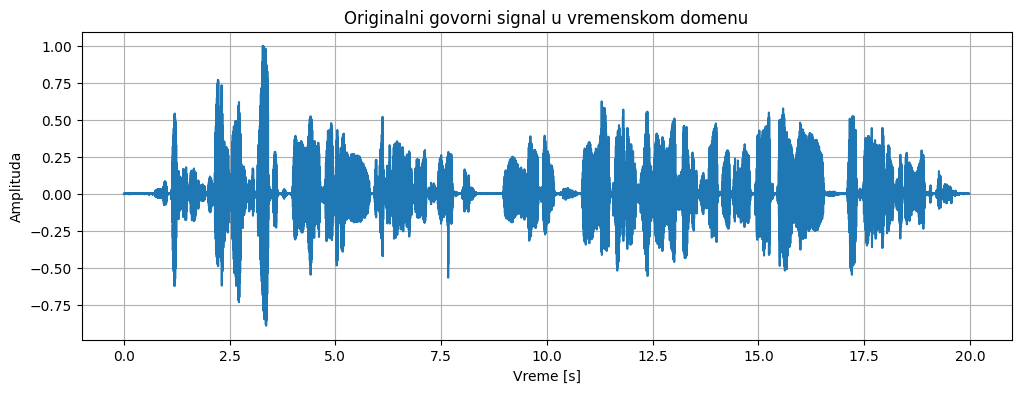

In [54]:
plt.figure()
plt.plot(t, x)
plt.xlabel("Vreme [s]")
plt.ylabel("Amplituda")
plt.title("Originalni govorni signal u vremenskom domenu")
plt.show()

## 5. Zumirani prikaz originalnog signala

Pošto govorni signal traje približno 20 sekundi, na celom vremenskom prikazu se ne vide detalji pojedinačnih oscilacija. Zbog toga se prikazuje i kraći vremenski interval, na primer prvih 0.5 sekundi signala.

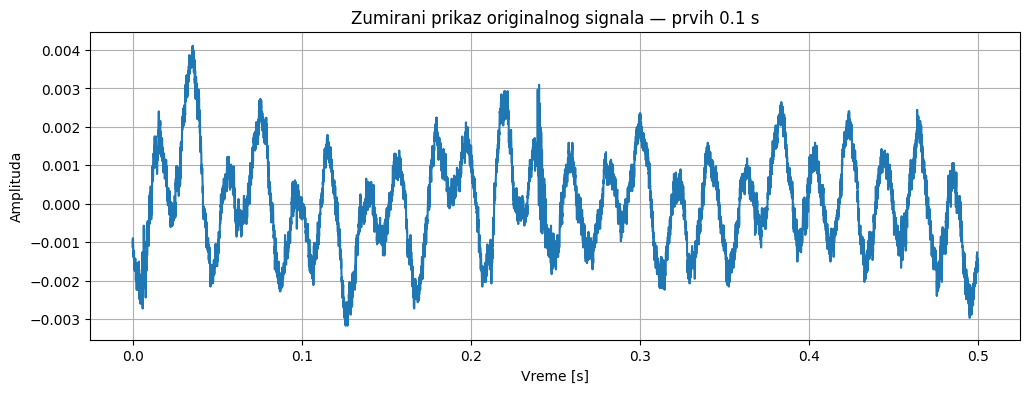

In [ ]:
time_limit = 0.5

# Pošto je fs broj odbiraka u jednoj sekundi, množenjem vremena sa fs
# dobija se broj odbiraka koji odgovara tom vremenskom intervalu.

samples_limit = int(time_limit * fs)

plt.figure()
plt.plot(t[:samples_limit], x[:samples_limit])
plt.xlabel("Vreme [s]")
plt.ylabel("Amplituda")
plt.title("Zumirani prikaz originalnog signala — prvih 0.1 s")
plt.show()